In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binomtest, f_oneway, levene
from statsmodels.tsa.stattools import adfuller, kpss
import statsmodels.api as sm

from runs.runs_entropy import Runs, Signal

In [48]:
def weierstrass_stationary(t, a=0.5, b=3, n_terms=12, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    phases = rng.uniform(0, 2 * np.pi, n_terms)
    W = np.zeros_like(t, dtype=float)
    for n, phi in enumerate(phases):
        W += (a ** n) * np.cos(np.pi * (b ** n) * t + phi)
    return W

#  Łańcuch Markowa dla znaków ±1
def markov_signs(N, p_pos=0.6, p_neg=0.4, rng=None):
    assert abs(p_pos + p_neg - 1) < 1e-6
    rng = np.random.default_rng() if rng is None else rng
    signs = np.empty(N, dtype=int)
    signs[0] = rng.choice([-1, 1])
    for i in range(1, N):
        if signs[i-1] == 1:
            signs[i] = 1 if rng.random() < p_pos else -1
        else:
            signs[i] = -1 if rng.random() < p_neg else 1
    return signs

#  Szum run-length (AR-1)
def runlength_noise(N, a=1.0, p_pos=0.6, p_neg=0.4,
                    rho=0.98, scale=0.05, seed=None):
    rng   = np.random.default_rng(seed)
    signs = markov_signs(N, p_pos, p_neg, rng)
    eps   = a * signs
    x     = np.empty(N)
    x_prev = 0.0
    for i, e in enumerate(eps):
        x_prev = rho * x_prev + scale * e
        x[i]   = x_prev
    return x, eps

#  SD1a / SD1d
def sd1(signal):
    diffs    = np.diff(signal)
    pos_mask = diffs >= 0
    sd1a = np.sqrt(np.var(diffs[pos_mask], ddof=1) / 2) if pos_mask.sum() > 1 else np.nan
    sd1d = np.sqrt(np.var(diffs[~pos_mask], ddof=1) / 2) if (~pos_mask).sum() > 1 else np.nan
    return sd1a, sd1d


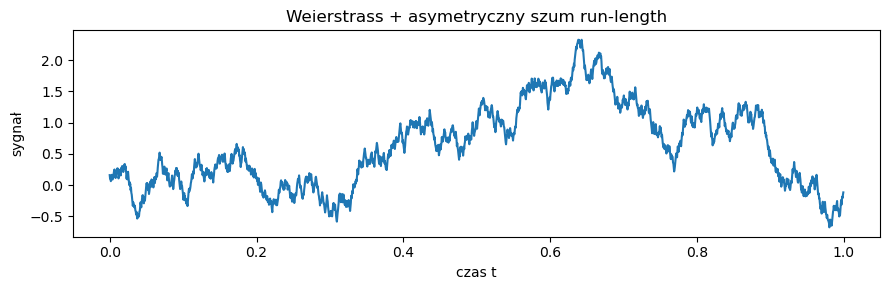

In [61]:
N = 2_000
t = np.linspace(0, 1, N, endpoint=False)
W = weierstrass_stationary(t, rng=np.random.default_rng(123))
noise, _ = runlength_noise(N,a=1.0, p_pos=0.51, p_neg=0.49,
        rho=0.98, scale=0.05, seed=2025)
signal = W + noise

plt.figure(figsize=(9, 3))
plt.plot(t, signal)
plt.title("Weierstrass + asymetryczny szum run-length")
plt.xlabel("czas t"); plt.ylabel("sygnał")
plt.tight_layout(); plt.show()

In [62]:
def stationarity_tests(signal, n_blocks=10, max_lag_lb=20):
    print("ADF  p =", adfuller(signal, autolag="AIC")[1])
    print("KPSS p =", kpss(signal, regression='c')[1])
    chunks = np.array_split(signal, n_blocks)
    print("ANOVA średnich bloków p =", f_oneway(*chunks).pvalue)
    print("Levene wariancji bloków p =", levene(*chunks).pvalue)
    lbp = sm.stats.acorr_ljungbox(signal, lags=max_lag_lb, return_df=True)["lb_pvalue"].iloc[-1]
    print(f"Ljung-Box (lag {max_lag_lb}) p =", lbp)

In [63]:
stationarity_tests(signal)


ADF  p = 0.5293666859510351
KPSS p = 0.01
ANOVA średnich bloków p = 0.0
Levene wariancji bloków p = 3.7205386748127664e-57
Ljung-Box (lag 20) p = 0.0


C:\Users\Bbicz\anaconda3\lib\site-packages\statsmodels\tsa\stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  warnings.warn(


In [64]:
def single_experiment(n_segments=100, seg_len=2_000,
                      p_pos=0.6, p_neg=0.4,
                      a=1.0, rho=0.98, scale=0.05,
                      seed=44):
    rng = np.random.default_rng(seed)
    wins_sd1, wins_har = 0, 0
    for _ in range(n_segments):
        x, _ = runlength_noise(seg_len, a, p_pos, p_neg, rho, scale,
                               seed=rng.integers(1e9))
        sd1a, sd1d = sd1(x)
        if sd1a > sd1d:
            wins_sd1 += 1

        r = Runs(Signal(x, annotations=np.zeros(len(x))))
        if r.HAR > r.HDR:
            wins_har += 1

    p_sd1 = binomtest(wins_sd1, n_segments, 0.5).pvalue
    p_har = binomtest(wins_har, n_segments, 0.5).pvalue
    return p_sd1, p_har

In [65]:
p_sd1, p_har = single_experiment()
print("p(SD1a > SD1d) =", p_sd1)
print("p(HAR  > HDR ) =", p_har)

p(SD1a > SD1d) = 0.48411841360729146
p(HAR  > HDR ) = 1.5777218104420236e-30


In [28]:
def bootstrap_experiment(n_boot=200,
                         n_segments=100, seg_len=2_000,
                         p_pos=0.6, p_neg=0.4,
                         a=1.0, rho=0.98, scale=0.05,
                         seed=2025):
    rng = np.random.default_rng(seed)
    p_sd1_list, p_har_list = [], []
    for _ in range(n_boot):
        p1, p2 = single_experiment(n_segments, seg_len,
                                   p_pos, p_neg,
                                   a, rho, scale,
                                   seed=rng.integers(1e9))
        p_sd1_list.append(p1)
        p_har_list.append(p2)

    print(f"Średnie p:  SD1 = {np.mean(p_sd1_list):.4f},  HAR = {np.mean(p_har_list):.4f}")

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].hist(p_sd1_list, bins=20, alpha=0.8)
    ax[0].set_title("Rozkład p (SD1a > SD1d)")
    ax[0].set_xlabel("p-value"); ax[0].set_ylabel("liczba prób")

    ax[1].hist(p_har_list, bins=20, alpha=0.8)
    ax[1].set_title("Rozkład p (HAR > HDR)")
    ax[1].set_xlabel("p-value")

    plt.tight_layout(); plt.show()

Średnie p:  SD1 = 0.5337,  HAR = 0.0000


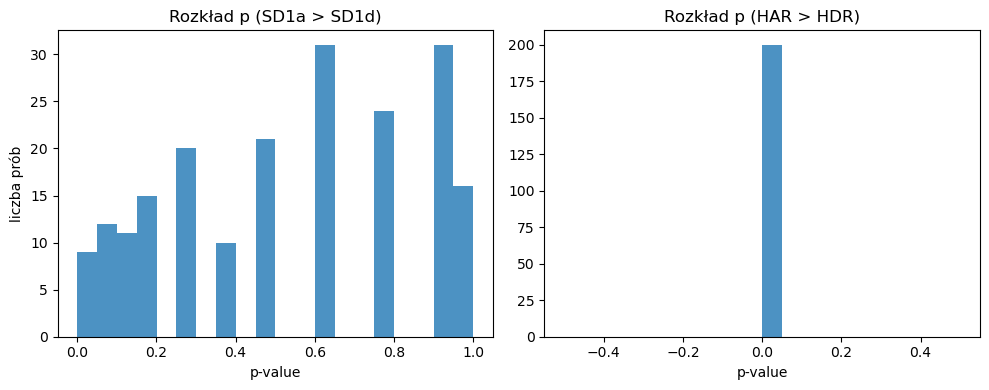

In [29]:
bootstrap_experiment()
